In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
import sys

if "../" not in sys.path:
    sys.path.append("../")

In [5]:
print("[sys.path]:", sys.path)

[sys.path]: ['/Users/nadir/.pyenv/versions/3.12.8/lib/python312.zip', '/Users/nadir/.pyenv/versions/3.12.8/lib/python3.12', '/Users/nadir/.pyenv/versions/3.12.8/lib/python3.12/lib-dynload', '', '/Users/nadir/Documents/research-project/code/experimentations/gymnasium/.venv/lib/python3.12/site-packages', '../']


In [6]:
import os
import time
import tqdm

import src.helpers as helpers
import src.environments.cristal as cristal

import src.controllers.dqn as dqn
import src.controllers.ppo as ppo
import src.controllers.clothoids as clothoids
import src.controllers.purepursuit as purepursuit

import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt

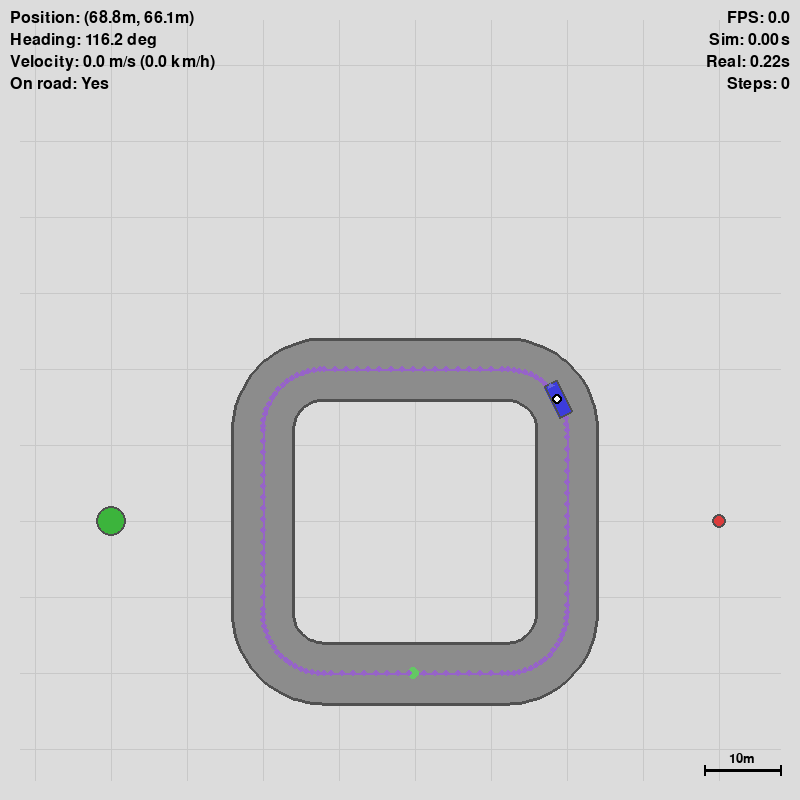

In [7]:
environment = cristal.make_environment(
    discrete=True,
    random_obstacles=False,
    render_mode="rgb_array",
    number_of_obstacles=0,
    random_spawn=True,
    dimensions=[40, 40]
)

environment.reset()

helpers.preview(environment)

In [8]:
# path = "/Users/nadir/Documents/research-project/code/experimentations/gymnasium/outputs/2026-02-08/21-12-59" # learned wit a static obstacle
path = "/Users/nadir/Documents/research-project/code/experimentations/gymnasium/outputs/2026-02-08/20-54-02" # learned with random obstacles

In [9]:
path = "/Users/nadir/Documents/research-project/code/experimentations/gymnasium/outputs/2026-02-09/13-59-36/"

In [10]:
controller = dqn.DQNController(environment)

controller.model = controller.model.load(os.path.join(path, "best_model.zip"))

In [12]:
observation, info = environment.reset()

for i in range(500):
    print(observation)
    action, _states = controller.get_action(observation=observation)
    
    observation, reward, terminated, truncated, info = environment.step(action)
    
    environment.unwrapped.overlay_manager.clear()
    controller.draw_debug(environment=environment, observation=observation, path=environment.unwrapped.path)
    
    helpers.preview(environment)

    if terminated or truncated:
        break

environment.close()

{'road/info': array([-0.00487518,  4.004875  ,  3.9951248 , -0.11723697,  0.        ,
        0.        ], dtype=float32), 'road/left_boundary': array([[ 8.862239 ,  5.0763245],
       [17.997478 ,  2.1245985],
       [18.898947 ,  6.493691 ],
       [20.54062  ,  8.054638 ],
       [25.006815 , 11.005432 ]], dtype=float32), 'road/right_boundary': array([[ 9.797988  , -2.8687603 ],
       [17.997478  ,  2.1245985 ],
       [23.527899  , -0.03107903],
       [27.962303  ,  5.0682573 ],
       [25.006815  , 11.005432  ]], dtype=float32), 'base/position': array([70.004875, 43.877552], dtype=float32), 'base/heading': array([1.4535594], dtype=float32), 'base/velocity': array([0.], dtype=float32), 'path/waypoints': array([[0.4858633 , 0.06213242, 0.        ],
       [0.97229683, 0.11942312, 0.        ],
       [1.4587303 , 0.17671382, 0.        ],
       [1.945164  , 0.23400453, 0.        ],
       [2.4315975 , 0.29129523, 0.        ],
       [2.918031  , 0.34858593, 0.        ],
       [3.4

KeyError: 'road/left_boundary'